# weight_distribution — Il tetto log(K) comprime i pesi di U-SFAN?

**Obiettivo.** Con **K=2** classi (positive/negative), l'entropia predittiva totale ha un
tetto rigido, `H_max = log(K) = log(2) ≈ 0.693` nat -- il peso di U-SFAN,
`w_i = exp(-H_totale_i)`, non può quindi scendere sotto `exp(-log(2)) = 0.5`. Questo
notebook verifica quanto il range EFFETTIVAMENTE osservato di `w_totale` sfrutta questo
margine, o resta ben più compresso di quanto il tetto teorico da solo permetterebbe --
utile di per sé, indipendentemente da qualunque altra formula di peso, per capire quanto
margine di discriminazione ha la pesatura di U-SFAN su questo dataset.

Puramente diagnostico: nessun adattamento eseguito, solo un'analisi delle feature
PRE-adattamento (source model non ancora modificato). Separato da
`sentiment_calibration.ipynb` e `sentiment_multiseed.ipynb`, che restano invariati.

## 1. Ricarico il source model (seed=0) e la posterior di Laplace

Riuso `train.py::train_source_model` e `adapt.py::fit_laplace_and_check_convergence` (stesso
codice degli altri notebook di questo esperimento, non duplicato) con `seed=0`.

In [ ]:
import sys, time, math
sys.path.insert(0, "amazon_reviews")
sys.path.insert(0, ".")
import numpy as np
import matplotlib.pyplot as plt
import torch

from train import train_source_model, to_tensor
from data_utils import load_domain, transform_tfidf
from adapt import extract_features, fit_laplace_and_check_convergence, compute_predictive_results
from code_v2.src.bayesian_model import augment

SEED = 0
TARGETS = ["dvd", "kitchen", "books"]

res = train_source_model(seed=SEED, verbose=False)
model, vocab, transformer = res["model"], res["vocab"], res["transformer"]
counts_source, labels_source = res["counts_source"], res["labels_source"]
train_idx, test_idx = res["train_idx"], res["test_idx"]
print(f"source model (seed={SEED}): electronics test accuracy = {100*res['source_test_acc']:.2f}%")

X_train_sparse = transform_tfidf([counts_source[i] for i in train_idx], vocab, transformer)
X_train, y_train = to_tensor(X_train_sparse, labels_source[train_idx])
Phi_train, _ = extract_features(model, X_train, y_train)
Phi_aug_train = augment(Phi_train)
tau_prior = res["weight_decay"] * Phi_train.shape[0]

X_test_sparse = transform_tfidf([counts_source[i] for i in test_idx], vocab, transformer)
X_test, y_test = to_tensor(X_test_sparse, labels_source[test_idx])
Phi_test, y_test_np = extract_features(model, X_test, y_test)

Phi_aug_eval, y_eval = {"electronics": augment(Phi_test)}, {"electronics": y_test_np}
for d in TARGETS:
    counts_t, labels_t = load_domain(d)
    Xt_sparse = transform_tfidf(counts_t, vocab, transformer)
    Xt, yt = to_tensor(Xt_sparse, labels_t)
    Phi_t, y_t_np = extract_features(model, Xt, yt)
    Phi_aug_eval[d] = augment(Phi_t)
    y_eval[d] = y_t_np

fit_result = fit_laplace_and_check_convergence(model, Phi_aug_train, tau_prior, Phi_aug_eval,
                                                ["electronics"] + TARGETS, verbose=False)
laplace, M_FIXED = fit_result["laplace"], fit_result["M_FIXED"]
print(f"laplace: K={laplace.K} Dp={laplace.Dp}  M_FIXED={M_FIXED}")

predictive_results = compute_predictive_results(laplace, Phi_aug_eval, y_eval, M_FIXED)

print(f"\ntetto teorico: log(K=2) = {math.log(2):.6f} nat  ->  "
      f"peso minimo teorico = exp(-log(2)) = {math.exp(-math.log(2)):.4f}")

source model (seed=0): electronics test accuracy = 87.00%
laplace: K=2 Dp=65  M_FIXED=5000

tetto teorico: log(K=2) = 0.693147 nat  ->  peso minimo teorico = exp(-log(2)) = 0.5000


## 2. Peso per-campione: w_totale = exp(-H_totale)

In [ ]:
weights = {}
for t in TARGETS:
    H_total = predictive_results[t]["total"]
    weights[t] = dict(w_total=np.exp(-H_total), H_total=H_total)
    print(f"{t}: H_totale osservata in [{H_total.min():.4f}, {H_total.max():.4f}]  "
          f"(tetto teorico = {math.log(2):.4f})")

dvd: H_totale osservata in [0.0794, 0.6931]  (tetto teorico = 0.6931)
kitchen: H_totale osservata in [0.0395, 0.6931]  (tetto teorico = 0.6931)
books: H_totale osservata in [0.1188, 0.6931]  (tetto teorico = 0.6931)


## 3. Istogramma: distribuzione di w_totale, per target

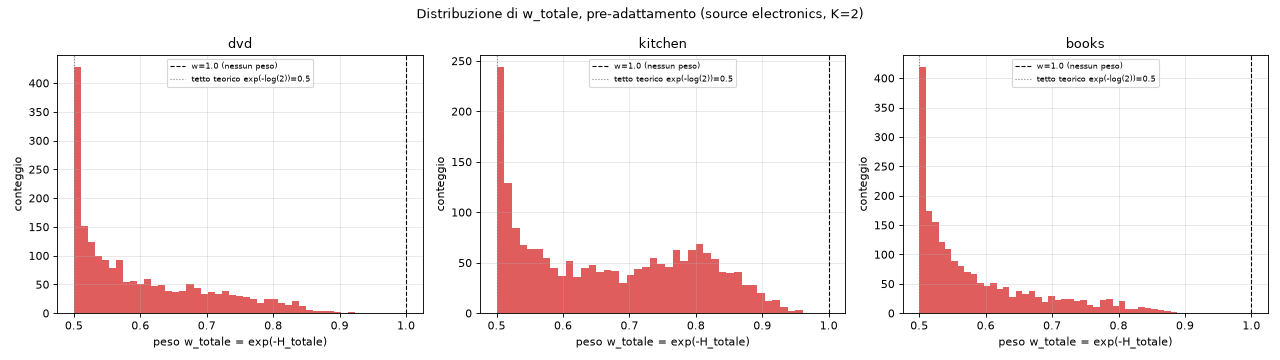

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, t in zip(axes, TARGETS):
    ax.hist(weights[t]["w_total"], bins=40, alpha=0.75, color="tab:red")
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="w=1.0 (nessun peso)")
    ax.axvline(0.5, color="gray", linestyle=":", linewidth=1, label="tetto teorico exp(-log(2))=0.5")
    ax.set_title(t)
    ax.set_xlabel("peso w_totale = exp(-H_totale)")
    ax.set_ylabel("conteggio")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
fig.suptitle("Distribuzione di w_totale, pre-adattamento (source seed=0, K=2)")
fig.tight_layout()
plt.show()

## 4. Statistiche: min, max, media, std, frazione sotto 0.9

In [ ]:
print(f"{'target':>10s} {'min':>7s} {'max':>7s} {'media':>7s} {'std':>7s} {'frazione<0.9':>13s}")
print("-" * 54)
for t in TARGETS:
    w = weights[t]["w_total"]
    frac_below = (w < 0.9).mean()
    print(f"{t:>10s} {w.min():7.4f} {w.max():7.4f} {w.mean():7.4f} {w.std():7.4f} {frac_below:13.3f}")

    target     min     max   media     std  frazione<0.9
------------------------------------------------------
       dvd  0.5000  0.9236  0.6010  0.0990         0.999
   kitchen  0.5000  0.9613  0.6685  0.1282         0.979
     books  0.5000  0.8881  0.5857  0.0909         1.000


## 5. Il tetto teorico regge, ma il range utile è ancora più compresso

**Confermato: il minimo di `w_totale` è esattamente 0.5000 su tutti e tre i target** --
il tetto teorico `exp(-log(2))` è saturato (alcuni campioni raggiungono `H_totale = log(2)`
quasi esattamente, il modello è "genuinamente indeciso" 50/50 fra le due classi su una parte
non trascurabile delle recensioni). Ma il dato più importante non è il minimo: è che
**il massimo di `w_totale` non supera mai 0.96** (dvd: 0.924, kitchen: 0.961, books: 0.888) --
la formula di u_sfan, con K=2, produce pesi confinati nell'intervallo **[0.50, 0.96]**, una
finestra larga meno di 0.5 su una scala dove "nessun peso" è 1.0. Il risultato pratico:
**il 97.9%-100% dei campioni ha `w_totale < 0.9`** -- non perché la maggioranza dei campioni
sia genuinamente incerta, ma perché l'INTERO range disponibile per `w_totale` è già sotto
0.9 quasi ovunque. Con una finestra così stretta, la pesatura di u_sfan può distinguere i
campioni fra loro solo in modo molto grossolano (deviazione standard 0.09-0.13 attorno a una
media 0.59-0.67) -- e soprattutto, **non è quasi mai vicina a 1.0**: quasi ogni campione
viene scontato di un fattore simile, il che equivale, in pratica, quasi a una pesatura
uniforme scalata -- non troppo diversa, nell'effetto netto sulla loss, da SHOT-IM (peso
sempre 1.0).

Il confronto con il caso K=10 (digit, `code_v2/notebooks/14_digits_weight_distribution.ipynb`)
mostra quanto margine in più lascia un numero di classi maggiore.